<a href="https://colab.research.google.com/github/jashvidesai2030/WeaklyConvexResearch/blob/main/epigraphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[1D] auto-estimated convexifying rho = 6.1319
[2D] auto-estimated convexifying rho = 6.9788


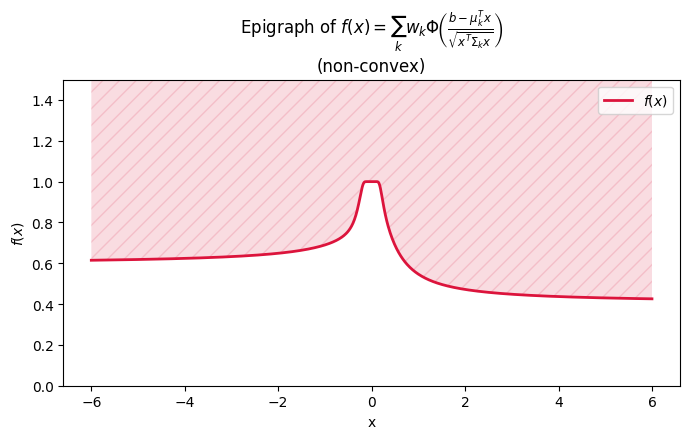

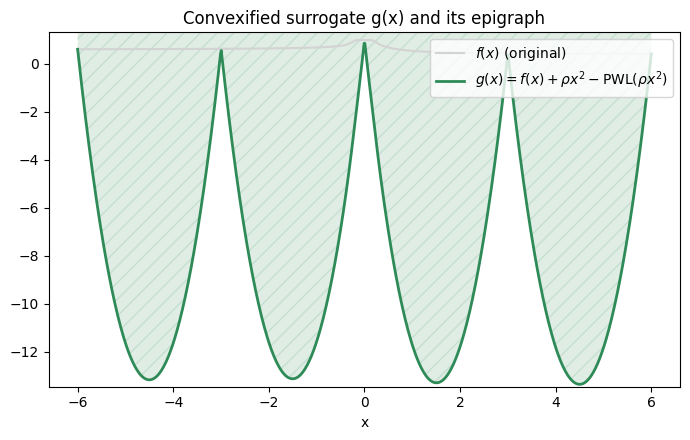

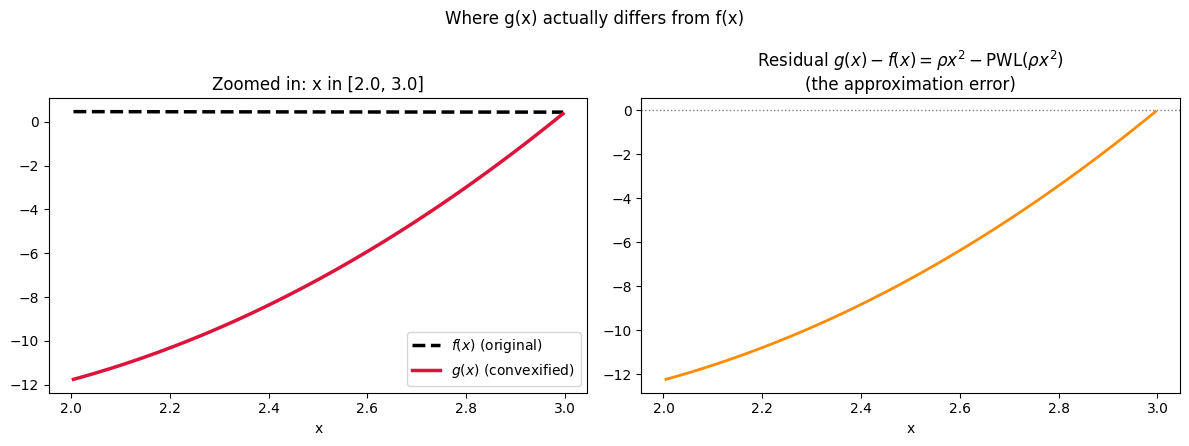

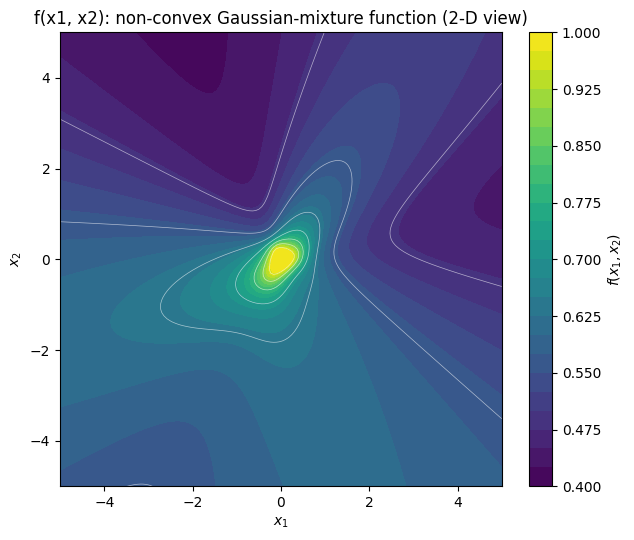

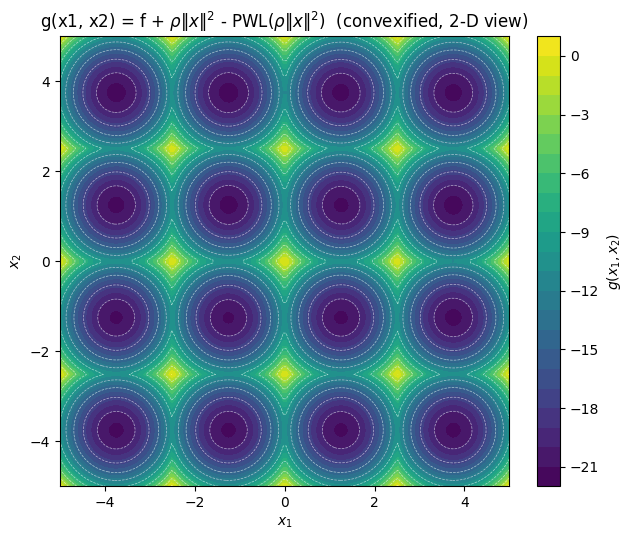

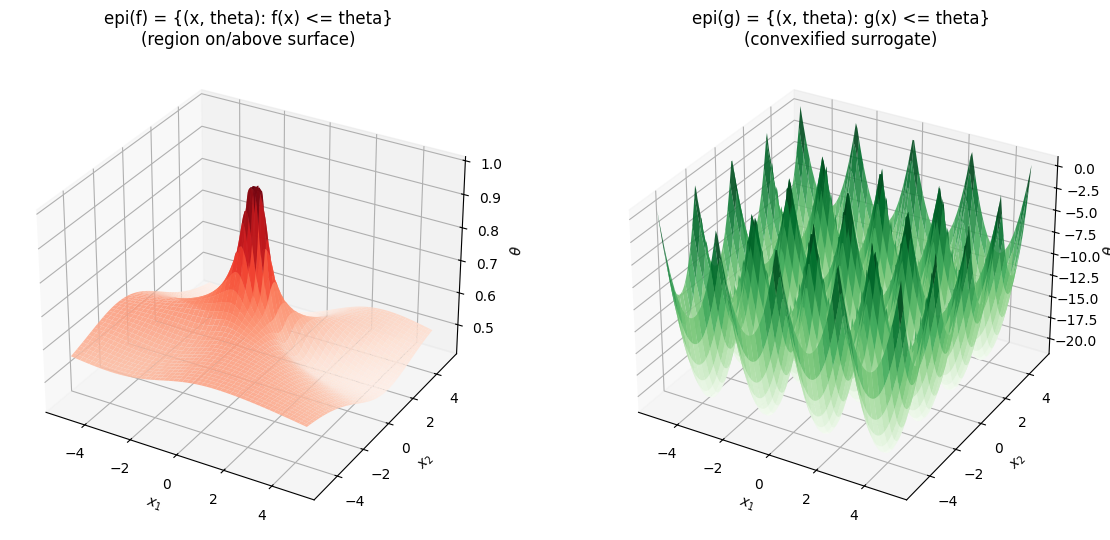

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (needed for projection="3d")

# 1. f(x): the Gaussian-mixture chance-constraint function
# f(x) = sum_k w_k * Phi( (b - mu_k . x) / sqrt(x . Sigma_k . x) )
def f(x, w, mu, Sigma, b):
    """
    x     : a single point, as a 1D array, e.g. np.array([1.5]) for n=1
            or np.array([1.5, -2.0]) for n=2
    w     : list of K mixture weights (sum to 1), e.g. [0.3, 0.4, 0.3]
    mu    : list of K mean vectors (each shape (n,))
    Sigma : list of K covariance matrices (each shape (n, n))
    b     : threshold in "a.x <= b"

    Returns a single number: f(x).
    """
    total = 0.0
    for wk, muk, Sk in zip(w, mu, Sigma):
        numerator = b - muk @ x
        # x @ Sk @ x is the quadratic form x^T Sigma_k x. Adding a tiny
        # epsilon avoids dividing by exactly 0 right at x = 0 (where,
        # mathematically, a.x=0 for every a, so f(0)=1 if b>=0 else 0 --
        # the epsilon just nudges us extremely close to that correct
        # answer without a special-case branch).
        denominator = np.sqrt(x @ Sk @ x) + 1e-9
        total += wk * norm.cdf(numerator / denominator)
    return total


def eval_f_grid_1d(x_grid, w, mu, Sigma, b):
    """f(x) evaluated at every point of a 1-D grid"""
    return np.array([f(np.array([xi]), w, mu, Sigma, b) for xi in x_grid])


def eval_f_grid_2d(X1, X2, w, mu, Sigma, b):
    """
    f(x1, x2) evaluated on a 2-D meshgrid (X1, X2), both shape (n_grid, n_grid).
    """
    n_rows, n_cols = X1.shape
    out = np.zeros_like(X1)
    for i in range(n_rows):
        for j in range(n_cols):
            out[i, j] = f(np.array([X1[i, j], X2[i, j]]), w, mu, Sigma, b)
    return out


# 2. Piecewise-linear (PWL) approximations of rho * t^2
#   pwl_secant()       "connect the dots" through sample points of the
#                       curve. Lies slightly ABOVE the true curve between
#                       dots (an over-estimate). This is what we use below
#                       to build g(x).

def pwl_secant(t, rho, lo, hi, n_breaks=9):
    """Connect-the-dots PWL approx of rho*t^2 on [lo, hi]."""
    bp = np.linspace(lo, hi, n_breaks)   # the breakpoints ("dots")
    vals = rho * bp ** 2                  # true curve height at each dot
    return np.interp(t, bp, vals)         # straight-line interpolation elsewhere

def estimate_convexifying_rho_1d(f_vals_on_grid, x_grid, safety=1.5, pct=1.0):
    """
    Picks rho large enough that h(x) = f(x) + rho*x^2 is (approximately)
    convex, i.e. rho >= -f''(x)/2 everywhere. Estimates f'' with two
    nested finite differences, and uses a low percentile (not the raw
    min) so one noisy point doesn't force rho absurdly high.
    """
    dx = x_grid[1] - x_grid[0]
    d2f = np.gradient(np.gradient(f_vals_on_grid, dx), dx)
    rho_min = max(0.0, -np.percentile(d2f, pct) / 2.0)
    return safety * rho_min

# 3. PART 1 : n = 1  (x is a single number)
w1 = [0.3, 0.4, 0.3]
mu1 = [np.array([-2.5]), np.array([0.6]), np.array([2.8])]
Sigma1 = [np.array([[1.2]]), np.array([[0.9]]), np.array([[1.4]])]
b1 = 0.8

x_grid = np.linspace(-6, 6, 800)
f_vals = eval_f_grid_1d(x_grid, w1, mu1, Sigma1, b1)

rho1 = estimate_convexifying_rho_1d(f_vals, x_grid)
rho1 = max(rho1, 0.05)  # keep a visible quadratic even if f already looked ~convex
print(f"[1D] auto-estimated convexifying rho = {rho1:.4f}")

# Number of PWL breakpoints. The worst-case gap between rho*t^2 and its
# chord approximation over spacing Delta is rho*Delta^2/4 -- with a big
# rho and only a few breakpoints that gap can swamp f(x) entirely, so we
# use a reasonably fine grid here.
n_breaks_1d = 5
bp1 = np.linspace(x_grid.min(), x_grid.max(), n_breaks_1d)
pwl_vals = pwl_secant(x_grid, rho1, bp1[0], bp1[-1], n_breaks_1d)

# g(x) = f(x) + rho*x^2 - PWL(rho*x^2)
g_vals = f_vals + rho1 * x_grid ** 2 - pwl_vals

# Plot 1: f(x) and its epigraph
fig, ax = plt.subplots(figsize=(7, 4.5))
theta_max = f_vals.max() * 1.3 + 0.2
ax.plot(x_grid, f_vals, color="crimson", lw=2, label=r"$f(x)$")
ax.fill_between(x_grid, f_vals, theta_max, color="crimson", alpha=0.15,
                 hatch="//", edgecolor="crimson", linewidth=0)
ax.set_ylim(0, theta_max)
ax.set_xlabel("x")
ax.set_ylabel(r"$f(x)$")
ax.set_title(r"Epigraph of $f(x) = \sum_k w_k \Phi\!\left(\frac{b-\mu_k^Tx}{\sqrt{x^T\Sigma_k x}}\right)$"
             "\n(non-convex)")
ax.legend(loc="upper right")
fig.tight_layout()

# --- Plot 2: g(x) vs f(x), and g's epigraph -----------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
theta_max_g = g_vals.max() * 1.3 + 0.2
ax.plot(x_grid, f_vals, color="lightgray", lw=1.5, label=r"$f(x)$ (original)")
ax.plot(x_grid, g_vals, color="seagreen", lw=2,
        label=r"$g(x) = f(x)+\rho x^2 - \mathrm{PWL}(\rho x^2)$")
ax.fill_between(x_grid, g_vals, theta_max_g, color="seagreen", alpha=0.15,
                 hatch="//", edgecolor="seagreen", linewidth=0)
ax.set_ylim(min(0, g_vals.min() - 0.1), theta_max_g)
ax.set_xlabel("x")
ax.set_title("Convexified surrogate g(x) and its epigraph")
ax.legend(loc="upper right")
fig.tight_layout()

# --- Plot 2b: zoomed-in, high-contrast look at f(x) vs g(x) -------------------------
zoom_lo, zoom_hi = 2.0, 3.0   # pick any window; more breakpoints fall in a
                               # wider window, so more ripples become visible
zoom_mask = (x_grid >= zoom_lo) & (x_grid <= zoom_hi)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(x_grid[zoom_mask], f_vals[zoom_mask], color="black", lw=2.5, ls="--",
         label=r"$f(x)$ (original)")
ax1.plot(x_grid[zoom_mask], g_vals[zoom_mask], color="crimson", lw=2.5,
         label=r"$g(x)$ (convexified)")
ax1.set_xlabel("x")
ax1.set_title(f"Zoomed in: x in [{zoom_lo}, {zoom_hi}]")
ax1.legend()

ax2.plot(x_grid[zoom_mask], (g_vals - f_vals)[zoom_mask], color="darkorange", lw=2)
ax2.axhline(0, color="gray", lw=1, ls=":")
ax2.set_xlabel("x")
ax2.set_title(r"Residual $g(x)-f(x) = \rho x^2 - \mathrm{PWL}(\rho x^2)$" "\n(the approximation error)")

fig.suptitle("Where g(x) actually differs from f(x)")
fig.tight_layout()

# 4. PART 2 : n = 2  (x = (x1, x2))
# Here x is a 2-vector. Plotted as 2-D contour/
# heatmap plots (color = function value), plus a 3-D epigraph plot.

w2 = [0.35, 0.4, 0.25]
mu2 = [np.array([-2.0, 1.0]), np.array([1.5, -1.5]), np.array([0.5, 2.0])]
Sigma2 = [
    np.array([[1.4, 0.2], [0.2, 1.0]]),
    np.array([[0.9, -0.1], [-0.1, 1.2]]),
    np.array([[1.1, 0.0], [0.0, 0.8]]),
]
b2 = 0.8

n_grid = 150
x1 = np.linspace(-5, 5, n_grid)
x2 = np.linspace(-5, 5, n_grid)
X1, X2 = np.meshgrid(x1, x2)
F2 = eval_f_grid_2d(X1, X2, w2, mu2, Sigma2, b2)

# Estimate a convexifying rho by reusing the 1-D idea along several lines
# through the origin at different angles, and taking the worst case.
rho2_candidates = []
for ang in np.linspace(0, np.pi, 6, endpoint=False):
    direction = np.array([np.cos(ang), np.sin(ang)])
    t = np.linspace(-5, 5, 400)
    f_line = np.array([f(ti * direction, w2, mu2, Sigma2, b2) for ti in t])
    dt = t[1] - t[0]
    d2 = np.gradient(np.gradient(f_line, dt), dt)
    rho2_candidates.append(max(0.0, -np.percentile(d2, 1.0) / 2.0))
rho2 = max(1.5 * max(rho2_candidates), 0.05)
print(f"[2D] auto-estimated convexifying rho = {rho2:.4f}")

# rho*(x1^2 + x2^2) is separable, so we approximate x1^2 and x2^2
# independently with the same 1-D pwl_secant() and just add the results.
n_breaks_2d = 5
bp2 = np.linspace(-5, 5, n_breaks_2d)
PWL_X1 = pwl_secant(X1, rho2, bp2[0], bp2[-1], n_breaks_2d)
PWL_X2 = pwl_secant(X2, rho2, bp2[0], bp2[-1], n_breaks_2d)
G2 = F2 + rho2 * (X1 ** 2 + X2 ** 2) - (PWL_X1 + PWL_X2)

# --- Plot 3: f(x1, x2) as a 2-D contour/heatmap -------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 5.5))
cs = ax.contourf(X1, X2, F2, levels=25, cmap="viridis")
ax.contour(X1, X2, F2, levels=8, colors="white", linewidths=0.5, alpha=0.6)
fig.colorbar(cs, ax=ax, label=r"$f(x_1,x_2)$")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title("f(x1, x2): non-convex Gaussian-mixture function (2-D view)")
fig.tight_layout()

# --- Plot 4: g(x1, x2), same style -- should look close to plot 4 ------------------
fig, ax = plt.subplots(figsize=(6.5, 5.5))
cs = ax.contourf(X1, X2, G2, levels=25, cmap="viridis")
ax.contour(X1, X2, G2, levels=8, colors="white", linewidths=0.5, alpha=0.6)
fig.colorbar(cs, ax=ax, label=r"$g(x_1,x_2)$")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title(r"g(x1, x2) = f + $\rho\|x\|^2$ - PWL($\rho\|x\|^2$)  (convexified, 2-D view)")
fig.tight_layout()

# --- Plot 5: true 3-D epigraphs (theta axis) for the 2-D domain --------------
fig = plt.figure(figsize=(12, 5.5))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(X1, X2, F2, cmap="Reds", alpha=0.9, linewidth=0, antialiased=True)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$"); ax.set_zlabel(r"$\theta$")
ax.set_title("epi(f) = {(x, theta): f(x) <= theta}\n(region on/above surface)")

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.plot_surface(X1, X2, G2, cmap="Greens", alpha=0.9, linewidth=0, antialiased=True)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$"); ax.set_zlabel(r"$\theta$")
ax.set_title("epi(g) = {(x, theta): g(x) <= theta}\n(convexified surrogate)")

fig.tight_layout()

# plt.show()